# **Atividade 1 (Ajuste de Curvas)**

A tabela [Embalagens](https://drive.google.com/file/d/1_MtJrJmrDbKMKUbdG9xnokc5002X9JY-/view?usp=drive_link) é uma amostra do resultado de um estudo sobre a relação entre a duração de certas operações (segundos) para embalar determinados objetos e o volume que eles ocupam (em dm³).

a) Crie um código em Python para fazer o diagrama de dispersão desses dados.

b) Crie um código em Python para fazer um ajuste do tipo Regressão Linear aos dados dispostos no diagrama.

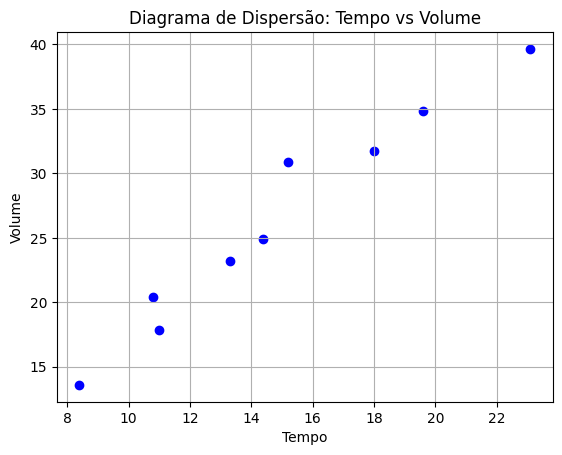

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Embalagens.csv", sep=';')

x = 'Tempo'
y = 'Volume'


plt.scatter(df[x], df[y], color='blue')
plt.xlabel("Tempo")
plt.ylabel("Volume")
plt.title(f'Diagrama de Dispersão: {x} vs {y}')
plt.grid()
plt.show()

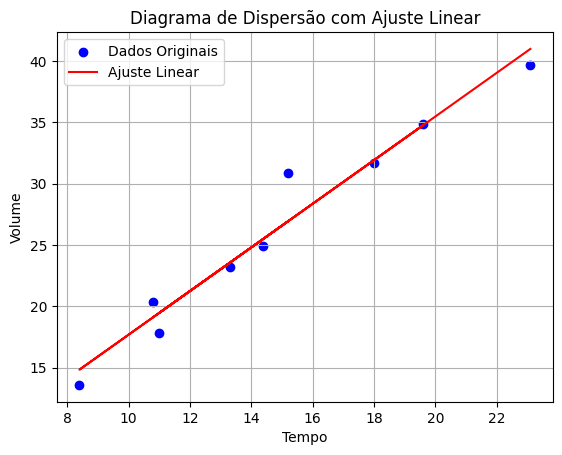

Coeficiente Angular (slope): 1.7788207457883773
Coeficiente Linear (intercept): -0.10735730960943002
Coeficiente de Determinação (R²): 0.9593328977473818


In [16]:
# Código para o item b)
from scipy.stats import linregress

df['Tempo'] = pd.to_numeric(df['Tempo'], errors='coerce')
df['Volume'] = pd.to_numeric(df['Volume'], errors='coerce')

df = df.dropna(subset=['Tempo', 'Volume'])

x = df['Tempo']
y = df['Volume']

slope, intercept, r_value, p_value, std_err = linregress(x, y)

ajuste_y = slope * x + intercept

plt.scatter(x, y, color='blue', label='Dados Originais')
plt.plot(x, ajuste_y, color='red', label='Ajuste Linear')
plt.xlabel("Tempo")
plt.ylabel("Volume")
plt.title("Diagrama de Dispersão com Ajuste Linear")
plt.legend()
plt.grid()
plt.show()

print("Coeficiente Angular (slope):", slope)
print("Coeficiente Linear (intercept):", intercept)
print("Coeficiente de Determinação (R²):", r_value**2)


# **Atividade 2 (Regra dos Trapézios)**

Crie uma função chamada *trapezio* em Python que, inseridas uma função $f(x)$, um intervalo $[a , b]$ e o número $n$ de subdivisões, a função *trapezio(f,a,b,n)* calcula valor de $\int_a^b f(x)dx$ utilizando a Regra dos Trapézios.



In [17]:
import numpy as np

In [19]:
# Código completo para a Regra dos Trapézios
def trapezio(f, a, b, n):
    h = (b - a) / n

    integral = 0.5 * (f(a) + f(b))
    for i in range(1, n):
        integral += f(a + i * h)

    integral *= h
    return integral


# **Atividade 3 (Regra de Simpson)**

Crie uma função chamada *simpson* em Python que, inseridas uma função $f(x)$, um intervalo $[a,b]$ e o número $n$ de subdivisões, a função *simpson(f,a,b,n)* calcula valor de $\int_a^bf(x)dx$ utilizando a Regra de Simpson.


In [18]:
def simpson(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("O número de subdivisões (n) deve ser par para a Regra de Simpson.")

    h = (b - a) / n

    integral = f(a) + f(b)

    for i in range(1, n, 2):
        integral += 4 * f(a + i * h)

    for i in range(2, n-1, 2):
        integral += 2 * f(a + i * h)

    integral *= h / 3
    return integral


# **Atividade 4**

Utilizando os códigos da Regra dos Trapézios e Regra de Simpson que você criou, calcule o valor aproximado das seguintes integrais:

a) $\int_{-10}^{10} \frac{e^{-x^2}}{\sqrt{\pi}}dx$, com $n = 20$.

b) $\int_2^5 \frac{x^2}{\sqrt{1+x^2}}dx$, com $n = 50$.

c) $\int_0^{30} \cos(t^2)dt$, com $n = 48$.


Obs.: Crie um linha de código para cada integral.

In [20]:
# a)
def func_a(x):
    return np.exp(-x**2) / np.sqrt(np.pi)

In [21]:
print("Trapezio:", trapezio(func_a, -10, 10, 20))
print("Simpson:", simpson(func_a, -10, 10, 20))

Trapezio: 1.0001034463724081
Simpson: 0.9435667979070801


In [22]:
# b)
def func_b(x):
    return (2 * x) / np.sqrt(1 + x**2)


In [23]:
print("Trapezio:", trapezio(func_b, 1, 5, 50))
print("Simpson:", simpson(func_b, 1, 5, 50))

Trapezio: 7.369242914797003
Simpson: 7.369611540898283


In [24]:
# c)
def func_c(t):
    return np.cos(t**2)


In [25]:
print("Trapezio", trapezio(func_c, 0, 3, 48))
print("Simpson:", simpson(func_c, 0, 3, 48))

Trapezio 0.702056043293844
Simpson: 0.7028741661402532
